# 04 - Model Explainability

## Reliable Machine-Failure Prediction Under Imbalanced and Corrupted Sensor Data

The previous notebooks established the selected Random Forest model and
evaluated its robustness under sensor noise, missing sensor measurements,
and limited training data.

This notebook investigates how the selected model makes its predictions.

Two explainability methods are used:

1. Random Forest feature importance
2. SHAP analysis

Feature importance is used to identify which input variables have the
greatest overall influence on the Random Forest.

SHAP is then used to explain how individual feature values contribute to
specific machine-failure predictions.

The objective is to make the prediction system more interpretable and useful
for engineering decision-making.

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

project_root = Path.cwd().parent

src_path = project_root / "src"

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

print("Project root:", project_root)
print("Source path:", src_path)

Project root: c:\Users\aacaa\Documents\reliable-machine-failure-prediction
Source path: c:\Users\aacaa\Documents\reliable-machine-failure-prediction\src


In [2]:
from data_loader import (
    load_ai4i_data,
    create_model_data
)

from preprocessing import create_preprocessor

print("Project functions imported successfully.")

Project functions imported successfully.


In [3]:
data = load_ai4i_data()

X, y = create_model_data(data)

print("Dataset shape:", data.shape)
print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nFeatures:")
print(list(X.columns))

print("\nTarget distribution:")
print(y.value_counts())

Dataset shape: (10000, 12)
Feature matrix shape: (10000, 6)
Target shape: (10000,)

Features:
['Type', 'Air temperature', 'Process temperature', 'Rotational speed', 'Torque', 'Tool wear']

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

# First split: 70% training and 30% temporary data
X_train, X_temporary, y_train, y_temporary = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: divide temporary data equally
X_validation, X_test, y_validation, y_test = train_test_split(
    X_temporary,
    y_temporary,
    test_size=0.50,
    random_state=42,
    stratify=y_temporary
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_validation.shape)
print("Test shape:", X_test.shape)

print("\nFailure counts:")
print("Training:", y_train.sum())
print("Validation:", y_validation.sum())
print("Test:", y_test.sum())

Training shape: (7000, 6)
Validation shape: (1500, 6)
Test shape: (1500, 6)

Failure counts:
Training: 237
Validation: 51
Test: 51


In [5]:
tree_preprocessor = create_preprocessor(
    scale_numeric=False
)

X_train_tree = tree_preprocessor.fit_transform(
    X_train
)

X_validation_tree = tree_preprocessor.transform(
    X_validation
)

X_test_tree = tree_preprocessor.transform(
    X_test
)

print("Training transformed shape:", X_train_tree.shape)
print("Validation transformed shape:", X_validation_tree.shape)
print("Test transformed shape:", X_test_tree.shape)

Training transformed shape: (7000, 8)
Validation transformed shape: (1500, 8)
Test transformed shape: (1500, 8)


In [6]:
random_forest_model = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_tree,
    y_train
)

print("Selected Random Forest trained successfully.")

Selected Random Forest trained successfully.


In [7]:
feature_names = tree_preprocessor.get_feature_names_out()

print("Features used by the Random Forest:")

for name in feature_names:
    print(name)

Features used by the Random Forest:
numeric__Air temperature
numeric__Process temperature
numeric__Rotational speed
numeric__Torque
numeric__Tool wear
categorical__Type_H
categorical__Type_L
categorical__Type_M


In [8]:
feature_importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": random_forest_model.feature_importances_
    }
)

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

display(
    feature_importance_df.round(4)
)

,Feature,Importance
0,numeric__Torque,0.3245
1,numeric__Rotational speed,0.2372
2,numeric__Tool wear,0.1671
3,numeric__Air temperature,0.1227
4,numeric__Process temperature,0.1221
5,categorical__Type_L,0.0123
6,categorical__Type_M,0.0083
7,categorical__Type_H,0.0058


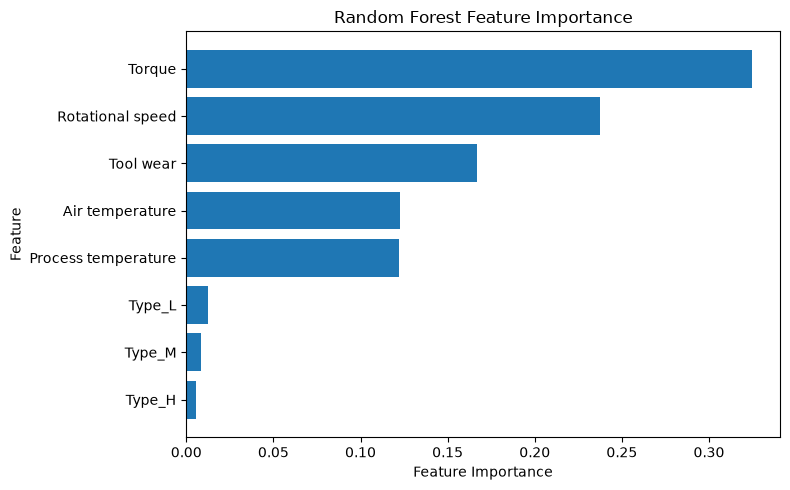

In [9]:
feature_importance_plot = feature_importance_df.copy()

feature_importance_plot["Feature"] = (
    feature_importance_plot["Feature"]
    .str.replace("numeric__", "", regex=False)
    .str.replace("categorical__", "", regex=False)
)

feature_importance_plot = (
    feature_importance_plot
    .sort_values("Importance", ascending=True)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    feature_importance_plot["Feature"],
    feature_importance_plot["Importance"]
)

ax.set_xlabel("Feature Importance")
ax.set_ylabel("Feature")

ax.set_title(
    "Random Forest Feature Importance"
)

plt.tight_layout()

plt.savefig(
    project_root
    / "figures"
    / "random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Feature-Importance Findings

The Random Forest feature-importance analysis shows that torque is the most
influential input feature, with an importance score of approximately 32.45%.

Rotational speed is the second most important feature at approximately
23.72%, followed by tool wear at approximately 16.71%.

Air temperature and process temperature also contribute to the model, with
importance values of approximately 12.27% and 12.21%, respectively.

The encoded machine-type variables have much smaller importance scores than
the numerical operating measurements.

These results indicate that the Random Forest relies mainly on machine
operating conditions such as torque, rotational speed, and tool wear when
separating failure and non-failure cases.

Feature importance describes how useful each variable was for the Random
Forest's decision splits. It should not be interpreted as a direct causal
relationship with machine failure.

## 5. SHAP Analysis

Random Forest feature importance provides a global view of which variables
are important to the model overall.

However, it does not explain how a particular feature value influences an
individual prediction.

SHAP analysis is used to provide both global and local explanations.

SHAP values indicate how each feature pushes a prediction toward either
machine failure or no failure.

This allows the model's decisions to be interpreted in more detail.

In [11]:
import shap

print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [12]:
explainer = shap.TreeExplainer(
    random_forest_model
)

print("SHAP TreeExplainer created successfully.")

SHAP TreeExplainer created successfully.


In [13]:
shap_values = explainer.shap_values(
    X_test_tree
)

print("SHAP values calculated successfully.")

SHAP values calculated successfully.


In [14]:
print("Type of SHAP output:", type(shap_values))

if isinstance(shap_values, list):
    print("Number of SHAP arrays:", len(shap_values))

    for i, values in enumerate(shap_values):
        print(
            f"SHAP array {i} shape:",
            values.shape
        )
else:
    print(
        "SHAP values shape:",
        np.array(shap_values).shape
    )

Type of SHAP output: <class 'numpy.ndarray'>
SHAP values shape: (1500, 8, 2)


In [15]:
failure_shap_values = shap_values[:, :, 1]

print(
    "Failure-class SHAP values shape:",
    failure_shap_values.shape
)

Failure-class SHAP values shape: (1500, 8)


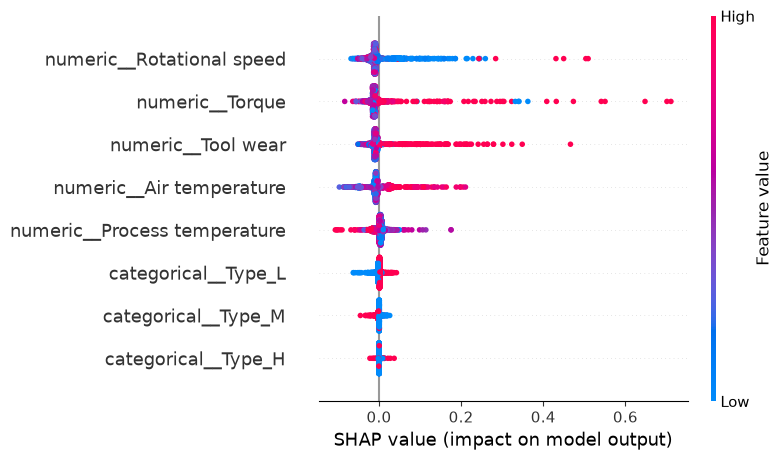

In [16]:
shap.summary_plot(
    failure_shap_values,
    X_test_tree,
    feature_names=feature_names,
    show=False
)

plt.tight_layout()

plt.savefig(
    project_root
    / "figures"
    / "shap_summary_plot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Global SHAP Findings

The SHAP summary plot provides additional information about both the
importance and direction of individual feature effects on the Random Forest
failure predictions.

Torque shows a strong positive contribution for many high-value observations.
This indicates that higher torque values generally push the model toward
predicting machine failure.

Rotational speed also has a strong influence. Lower rotational-speed values
frequently produce positive SHAP values, indicating that certain low-speed
operating conditions increase the model's predicted failure risk.

Higher tool-wear values generally push predictions toward failure, while
higher air-temperature values also tend to increase predicted failure risk.

Process temperature shows a weaker and more mixed relationship with the
model output.

The encoded machine-type variables have SHAP values concentrated close to
zero, indicating that machine type contributes relatively little compared
with the numerical operating measurements.

Overall, the SHAP analysis supports the earlier feature-importance results
while also showing the direction in which individual feature values
influence failure predictions.

These relationships describe the behaviour learned by the Random Forest and
should not be interpreted as direct causal relationships with machine failure.

In [17]:
# Find the first actual failure case in the test set
failure_indices = np.where(y_test.to_numpy() == 1)[0]

selected_failure_index = failure_indices[0]

print(
    "Selected failure-case index:",
    selected_failure_index
)

print(
    "Actual class:",
    y_test.iloc[selected_failure_index]
)

Selected failure-case index: 35
Actual class: 1


In [21]:
selected_threshold = 0.20

print("Selected decision threshold:", selected_threshold)

Selected decision threshold: 0.2


In [22]:
selected_failure_probability = random_forest_model.predict_proba(
    X_test_tree[selected_failure_index].reshape(1, -1)
)[0, 1]

selected_failure_prediction = int(
    selected_failure_probability >= selected_threshold
)

print("Actual class:", y_test.iloc[selected_failure_index])
print("Predicted failure probability:", round(selected_failure_probability, 4))
print("Predicted class:", selected_failure_prediction)

Actual class: 1
Predicted failure probability: 0.94
Predicted class: 1
